In [137]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import json
import os
import numpy as np
from datetime import datetime
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

In [138]:
# Configuration
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DELETE_RATIO = 0.01
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
TRAIN_EPOCHS = 10
SAVE_EPOCH = 0
RETRAIN_EPOCHS = 3
LOSS_NAME = "CrossEntropyLoss"
DATASET_TAG = "CIFAR10"

print(f"Configuration loaded:")
print(f"  Dataset: {DATASET_TAG}")
print(f"  Seed: {SEED}")
print(f"  Delete Ratio: {DELETE_RATIO}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Train Epochs: {TRAIN_EPOCHS}")
print(f"  Save Epoch: {SAVE_EPOCH}")
print(f"  Retrain Epochs: {RETRAIN_EPOCHS}")
print(f"  Loss: {LOSS_NAME}")

Configuration loaded:
  Dataset: CIFAR10
  Seed: 42
  Delete Ratio: 0.01
  Batch Size: 64
  Learning Rate: 0.001
  Train Epochs: 10
  Save Epoch: 0
  Retrain Epochs: 3
  Loss: CrossEntropyLoss


In [139]:
# Plot saving setup (dataset + technique + seed + delete ratio)
TECHNIQUE_NAME = "first_epoch_reversal"
seed_str = f"{SEED:04d}"
delete_ratio_str = f"{DELETE_RATIO:.4f}".rstrip("0").rstrip(".").replace(".", "p")
plot_output_dir = f"../results/plots/{DATASET_TAG}_{TECHNIQUE_NAME}_seed_{seed_str}_delete_{delete_ratio_str}"
os.makedirs(plot_output_dir, exist_ok=True)


def save_plot(fig, filename):
    filepath = os.path.join(plot_output_dir, filename)
    fig.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"Saved plot: {filepath}")


print(f"Plot directory ready: {plot_output_dir}")

Plot directory ready: ../results/plots/CIFAR10_first_epoch_reversal_seed_0042_delete_0p01


In [140]:
# Import Membership Inference Attack (MIA) evaluation
import sys
sys.path.insert(0, '..')
from mia import evaluate_mia

print("✓ MIA module imported successfully")

✓ MIA module imported successfully


In [141]:
# Load and split MNIST/CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))   # CIFAR-10 mean and std (3 channels)
])

# Changed datasets.MNIST to datasets.CIFAR10
dataset = datasets.CIFAR10(
# dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

num_delete = int(DELETE_RATIO * len(dataset))
indices = np.random.permutation(len(dataset))

delete_idx = indices[:num_delete]
retain_idx = indices[num_delete:]

retain_set = Subset(dataset, retain_idx)
delete_set = Subset(dataset, delete_idx)

retain_loader = DataLoader(retain_set, batch_size=BATCH_SIZE, shuffle=True)
delete_loader = DataLoader(delete_set, batch_size=BATCH_SIZE, shuffle=True)

print("CIFAR-10 retain_loader and delete_loader ready")
print(f"Retain samples: {len(retain_set)}")
print(f"Delete samples: {len(delete_set)}")

CIFAR-10 retain_loader and delete_loader ready
Retain samples: 49500
Delete samples: 500


/Users/new/Desktop/unlearning/muvenv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [142]:
assert "retain_loader" in globals()
assert "delete_loader" in globals()

In [143]:

class SimpleCNN(nn.Module):
    """Simple CNN for MNIST/CIFAR-10 classification."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # nn.Conv2d(1, 32, 3, 1),
            nn.Conv2d(3, 32, 3, 1), # Changed 1 to 3 for RGB
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            # nn.Linear(5408, 10),     # Original for MNIST with 28x28 input
            nn.Linear(7200, 10)     # Changed 5408 to 7200 for 32x32 input
        )

    def forward(self, x):
        return self.net(x)

In [144]:
def train_with_checkpoint(
    model,
    loader,
    epochs=TRAIN_EPOCHS,
    save_epoch=SAVE_EPOCH,
    lr=LEARNING_RATE,
    device="cpu"
):
    """Train model and save checkpoint at specified epoch"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.to(device)

    os.makedirs("../models", exist_ok=True)
    ckpt_path = f"../models/{DATASET_TAG}_early_checkpoint_seed_{SEED:04d}_epoch{save_epoch}.pt"
    full_path = f"../models/{DATASET_TAG}_full_model_seed_{SEED:04d}.pt"

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for x, y in loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"Epoch {epoch}: loss = {epoch_loss / len(loader):.4f}")

        if epoch == save_epoch:
            torch.save(model.state_dict(), ckpt_path)
            print(f"✔ Early checkpoint saved at epoch {epoch}")

    torch.save(model.state_dict(), full_path)
    print(f"✔ Full model saved")

    return {
        "total_epochs": epochs,
        "save_epoch": save_epoch,
        "checkpoint_path": ckpt_path,
        "full_model_path": full_path,
        "epoch_indexing": "0-based"
    }

In [145]:
def first_epoch_reversal(
    model,
    retain_loader,
    checkpoint_path,
    epochs=RETRAIN_EPOCHS,
    lr=LEARNING_RATE,
    device="cpu"
):
    """Unlearn by reverting to early checkpoint and retraining"""
    model.load_state_dict(
        torch.load(checkpoint_path, map_location=device)
    )
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    start = time.time()

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for x, y in retain_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        print(f"Retrain Epoch {epoch}: loss = {epoch_loss / len(retain_loader):.4f}")

    unlearn_time = time.time() - start

    os.makedirs("../models", exist_ok=True)
    unlearned_path = f"../models/{DATASET_TAG}_reversal_unlearned_seed_{SEED:04d}.pt"
    torch.save(model.state_dict(), unlearned_path)
    print(f"✔ Unlearned model saved to: {unlearned_path}")

    return model, unlearn_time, unlearned_path

In [146]:
def evaluate(model, loader, device="cpu"):
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0.0

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            loss_sum += loss.item()
            preds = outputs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return {
        "accuracy": correct / total,
        "loss": loss_sum / len(loader)
    }


In [147]:
# Train baseline model with checkpoint
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

baseline_model = SimpleCNN()

train_meta = train_with_checkpoint(
    baseline_model,
    retain_loader,
    epochs=TRAIN_EPOCHS,
    save_epoch=SAVE_EPOCH,
    lr=LEARNING_RATE,
    device=device
)

# Perform first epoch reversal unlearning
unlearned_model = SimpleCNN()

unlearned_model, unlearn_time, unlearned_path = first_epoch_reversal(
    unlearned_model,
    retain_loader,
    checkpoint_path=train_meta["checkpoint_path"],
    epochs=RETRAIN_EPOCHS,
    lr=LEARNING_RATE,
    device=device
)

# Evaluate on retain and delete sets
retain_metrics = evaluate(unlearned_model, retain_loader, device)
delete_metrics = evaluate(unlearned_model, delete_loader, device)

print("\n" + "="*50)
print("EVALUATION RESULTS")
print("="*50)
print(f"Retain Set - Accuracy: {retain_metrics['accuracy']:.4f}, Loss: {retain_metrics['loss']:.4f}")
print(f"Delete Set - Accuracy: {delete_metrics['accuracy']:.4f}, Loss: {delete_metrics['loss']:.4f}")
print(f"Unlearning Time: {unlearn_time:.2f} seconds")
print("="*50)

Using device: cpu
Epoch 0: loss = 1.3925
✔ Early checkpoint saved at epoch 0
Epoch 1: loss = 1.0863
Epoch 2: loss = 0.9764
Epoch 3: loss = 0.9150
Epoch 4: loss = 0.8735
Epoch 5: loss = 0.8340
Epoch 6: loss = 0.8029
Epoch 7: loss = 0.7712
Epoch 8: loss = 0.7459
Epoch 9: loss = 0.7205
✔ Full model saved
Retrain Epoch 0: loss = 1.0934
Retrain Epoch 1: loss = 0.9823
Retrain Epoch 2: loss = 0.9079
✔ Unlearned model saved to: ../models/CIFAR10_reversal_unlearned_seed_0042.pt

EVALUATION RESULTS
Retain Set - Accuracy: 0.6944, Loss: 0.8847
Delete Set - Accuracy: 0.6000, Loss: 1.1404
Unlearning Time: 69.64 seconds


## Privacy Evaluation: Membership Inference Attack

Evaluate whether the unlearned model successfully forgets about the deleted data using MIA.
- **Baseline MIA**: Attack on the model trained on ALL data (including to-be-deleted)
- **Unlearned MIA**: Attack on the model after unlearning - should have lower attack accuracy

In [148]:
 # Train baseline model (full data) for MIA comparison
print("\n" + "="*60)
print("BASELINE MODEL (Trained on ALL data - for MIA comparison)")
print("="*60)

baseline_full_model = SimpleCNN()

baseline_train_meta = train_with_checkpoint(
    baseline_full_model,
    DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True),  # Train on ALL data
    epochs=TRAIN_EPOCHS,
    save_epoch=SAVE_EPOCH,
    lr=LEARNING_RATE,
    device=device
)

# Evaluate baseline on retain and delete sets
baseline_retain_metrics = evaluate(baseline_full_model, retain_loader, device)
baseline_delete_metrics = evaluate(baseline_full_model, delete_loader, device)

print(f"\nBaseline Model - Retain Accuracy: {baseline_retain_metrics['accuracy']:.4f}, Loss: {baseline_retain_metrics['loss']:.4f}")
print(f"Baseline Model - Delete Accuracy: {baseline_delete_metrics['accuracy']:.4f}, Loss: {baseline_delete_metrics['loss']:.4f}")


BASELINE MODEL (Trained on ALL data - for MIA comparison)
Epoch 0: loss = 1.3614
✔ Early checkpoint saved at epoch 0
Epoch 1: loss = 1.0834
Epoch 2: loss = 0.9794
Epoch 3: loss = 0.9144
Epoch 4: loss = 0.8703
Epoch 5: loss = 0.8315
Epoch 6: loss = 0.7952
Epoch 7: loss = 0.7656
Epoch 8: loss = 0.7447
Epoch 9: loss = 0.7155
✔ Full model saved

Baseline Model - Retain Accuracy: 0.7845, Loss: 0.6320
Baseline Model - Delete Accuracy: 0.7640, Loss: 0.6800


In [149]:
# MIA on Baseline Model (knows about deleted data)
print("\n" + "="*60)
print("MEMBERSHIP INFERENCE ATTACK (MIA) - BASELINE MODEL")
print("="*60)

mia_baseline = evaluate_mia(baseline_full_model, retain_loader, delete_loader, threshold=None)

print(f"MIA Accuracy:             {mia_baseline['mia_accuracy']:.4f}")
print(f"True Positive Rate (TPR): {mia_baseline['tpr']:.4f}")
print(f"False Positive Rate (FPR):{mia_baseline['fpr']:.4f}")
print(f"AUC-ROC:                  {mia_baseline.get('auc_roc', 'N/A')}")
print("\nInterpretation: Baseline model 'remembers' deleted data → High MIA accuracy")


MEMBERSHIP INFERENCE ATTACK (MIA) - BASELINE MODEL
MIA Accuracy:             0.5506
True Positive Rate (TPR): 0.5515
False Positive Rate (FPR):0.5360
AUC-ROC:                  N/A

Interpretation: Baseline model 'remembers' deleted data → High MIA accuracy


In [150]:
# MIA on Unlearned Model (should forget deleted data)
print("\n" + "="*60)
print("MEMBERSHIP INFERENCE ATTACK (MIA) - AFTER UNLEARNING")
print("="*60)

mia_unlearned = evaluate_mia(unlearned_model, retain_loader, delete_loader, threshold=None)

print(f"MIA Accuracy:             {mia_unlearned['mia_accuracy']:.4f}")
print(f"True Positive Rate (TPR): {mia_unlearned['tpr']:.4f}")
print(f"False Positive Rate (FPR):{mia_unlearned['fpr']:.4f}")
print(f"AUC-ROC:                  {mia_unlearned.get('auc_roc', 'N/A')}")

# Compare privacy improvement
mia_improvement = mia_baseline['mia_accuracy'] - mia_unlearned['mia_accuracy']
print(f"\nPrivacy Improvement: {mia_improvement:.4f} (Lower MIA accuracy = Better forgetting)")
print("Interpretation: Unlearned model should have lower MIA accuracy (harder to attack)")


MEMBERSHIP INFERENCE ATTACK (MIA) - AFTER UNLEARNING
MIA Accuracy:             0.5001
True Positive Rate (TPR): 0.4996
False Positive Rate (FPR):0.4520
AUC-ROC:                  N/A

Privacy Improvement: 0.0505 (Lower MIA accuracy = Better forgetting)
Interpretation: Unlearned model should have lower MIA accuracy (harder to attack)


## Per-Class Accuracy & Confusion Matrices

In [151]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def compute_confusion_matrix_and_per_class_metrics(model, loader, device="cpu"):
    """
    Compute confusion matrix and per-class accuracy metrics.
    
    Returns:
        cm: Confusion matrix (10x10 for MNIST)
        per_class_acc: Dictionary with per-class accuracy for each digit
        y_true_all: All true labels
        y_pred_all: All predicted labels
    """
    model.eval()
    y_true_all = []
    y_pred_all = []
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            y_true_all.extend(y.cpu().numpy())
            y_pred_all.extend(preds.cpu().numpy())
    
    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    
    # Compute confusion matrix
    cm = confusion_matrix(y_true_all, y_pred_all, labels=range(10))
    
    # Compute per-class accuracy
    per_class_acc = {}
    for digit in range(10):
        mask = (y_true_all == digit)
        if mask.sum() > 0:
            acc = (y_pred_all[mask] == digit).sum() / mask.sum()
            per_class_acc[digit] = acc
        else:
            per_class_acc[digit] = None
    
    return cm, per_class_acc, y_true_all, y_pred_all


def plot_confusion_matrix(cm, title, ax=None, cmap='Blues'):
    """Plot confusion matrix as heatmap."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, 
                xticklabels=range(10), yticklabels=range(10),
                cbar_kws={'label': 'Count'})
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(title, fontsize=12, fontweight='bold')
    return ax


print("Confusion matrix and per-class metrics functions loaded")

Confusion matrix and per-class metrics functions loaded



BASELINE MODEL - Per-Class Accuracy & Confusion Matrix

Per-Class Accuracy on RETAIN set:
----------------------------------------
  Digit 0: 0.7300
  Digit 1: 0.8344
  Digit 2: 0.7618
  Digit 3: 0.6157
  Digit 4: 0.7230
  Digit 5: 0.6646
  Digit 6: 0.8987
  Digit 7: 0.8078
  Digit 8: 0.9107
  Digit 9: 0.8988
Saved plot: ../results/plots/CIFAR10_first_epoch_reversal_seed_0042_delete_0p01/plot_01_baseline_confusion_matrix_retain.png


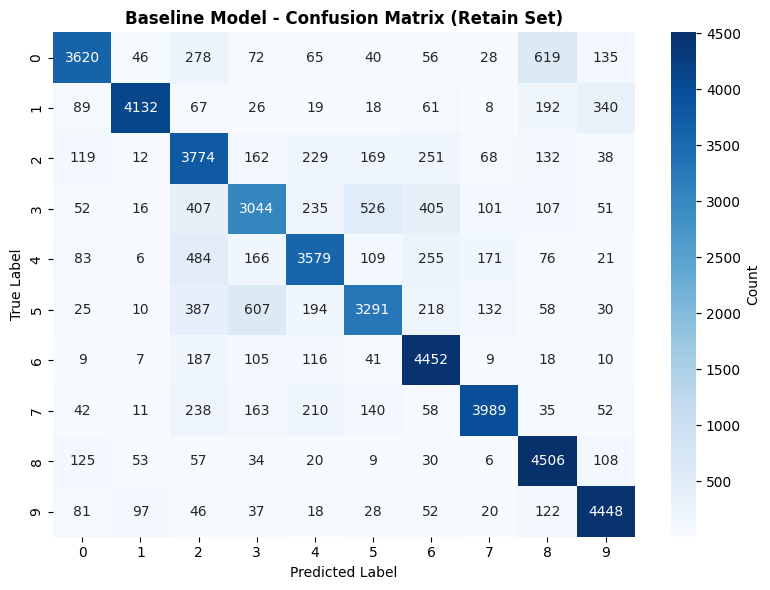

In [152]:
print("\n" + "="*70)
print("BASELINE MODEL - Per-Class Accuracy & Confusion Matrix")
print("="*70)

baseline_cm, baseline_per_class, _, _ = compute_confusion_matrix_and_per_class_metrics(
    baseline_full_model, retain_loader, device
)

# Display per-class accuracy
print("\nPer-Class Accuracy on RETAIN set:")
print("-" * 40)
for digit in range(10):
    acc = baseline_per_class[digit]
    if acc is not None:
        print(f"  Digit {digit}: {acc:.4f}")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
plot_confusion_matrix(baseline_cm, "Baseline Model - Confusion Matrix (Retain Set)", ax=ax)
plt.tight_layout()
save_plot(fig, "plot_01_baseline_confusion_matrix_retain.png")
plt.show()


UNLEARNED MODEL (First-Epoch Reversal) - Per-Class Accuracy & Confusion Matrix

Per-Class Accuracy on RETAIN set:
----------------------------------------
  Digit 0: 0.8004
  Digit 1: 0.7379
  Digit 2: 0.5640
  Digit 3: 0.6640
  Digit 4: 0.7857
  Digit 5: 0.6014
  Digit 6: 0.4764
  Digit 7: 0.5992
  Digit 8: 0.8426
  Digit 9: 0.8729
Saved plot: ../results/plots/CIFAR10_first_epoch_reversal_seed_0042_delete_0p01/plot_02_unlearned_confusion_matrix_retain.png


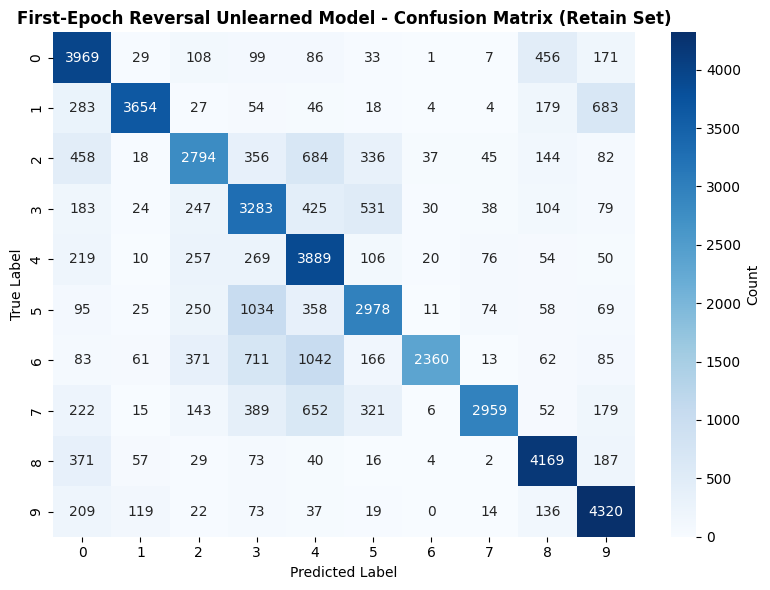

In [153]:
print("\n" + "="*70)
print("UNLEARNED MODEL (First-Epoch Reversal) - Per-Class Accuracy & Confusion Matrix")
print("="*70)

unlearned_cm, unlearned_per_class, _, _ = compute_confusion_matrix_and_per_class_metrics(
    unlearned_model, retain_loader, device
)

# Display per-class accuracy
print("\nPer-Class Accuracy on RETAIN set:")
print("-" * 40)
for digit in range(10):
    acc = unlearned_per_class[digit]
    if acc is not None:
        print(f"  Digit {digit}: {acc:.4f}")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
plot_confusion_matrix(unlearned_cm, "First-Epoch Reversal Unlearned Model - Confusion Matrix (Retain Set)", ax=ax)
plt.tight_layout()
save_plot(fig, "plot_02_unlearned_confusion_matrix_retain.png")
plt.show()

In [154]:
print("\n" + "="*70)
print("DELETE SET PERFORMANCE - Per-Class Accuracy")
print("="*70)
print("\nForgetting Score: How much baseline accuracy decreased per class")
print("(Higher = better forgetting)")

# Compute per-class metrics on DELETE set
baseline_delete_cm, baseline_delete_pc, _, _ = compute_confusion_matrix_and_per_class_metrics(
    baseline_full_model, delete_loader, device
)
unlearned_delete_cm, unlearned_delete_pc, _, _ = compute_confusion_matrix_and_per_class_metrics(
    unlearned_model, delete_loader, device
)

# Create comparison dataframe for DELETE set
delete_comparison_data = {
    'Digit': list(range(10)),
    'Baseline (Before)': [baseline_delete_pc[d] for d in range(10)],
    'Unlearned (After)': [unlearned_delete_pc[d] for d in range(10)],
}

# Forgetting scores
delete_comparison_data['Forgetting Score'] = [
    baseline_delete_pc[d] - unlearned_delete_pc[d] for d in range(10)
]

import pandas as pd
delete_comparison_df = pd.DataFrame(delete_comparison_data)
print("\n" + delete_comparison_df.to_string(index=False))

print("\n" + "="*70)
print("DELETE SET SUMMARY")
print("="*70)
print(f"\nAverage per-class accuracy on DELETE set:")
print(f"  Baseline (Before):     {delete_comparison_df['Baseline (Before)'].mean():.4f}")
print(f"  Unlearned (After):     {delete_comparison_df['Unlearned (After)'].mean():.4f}")

print(f"\nAverage Forgetting Score: {delete_comparison_df['Forgetting Score'].mean():.4f}")
print(f"Best Forgetting: Digit {delete_comparison_df['Forgetting Score'].idxmax()} ({delete_comparison_df['Forgetting Score'].max():.4f})")
print(f"Worst Forgetting: Digit {delete_comparison_df['Forgetting Score'].idxmin()} ({delete_comparison_df['Forgetting Score'].min():.4f})")


DELETE SET PERFORMANCE - Per-Class Accuracy

Forgetting Score: How much baseline accuracy decreased per class
(Higher = better forgetting)

 Digit  Baseline (Before)  Unlearned (After)  Forgetting Score
     0           0.609756           0.609756          0.000000
     1           0.812500           0.708333          0.104167
     2           0.760870           0.478261          0.282609
     3           0.607143           0.535714          0.071429
     4           0.800000           0.760000          0.040000
     5           0.520833           0.395833          0.125000
     6           0.847826           0.434783          0.413043
     7           0.838710           0.467742          0.370968
     8           0.923077           0.788462          0.134615
     9           0.882353           0.823529          0.058824

DELETE SET SUMMARY

Average per-class accuracy on DELETE set:
  Baseline (Before):     0.7603
  Unlearned (After):     0.6002

Average Forgetting Score: 0.1601
Best 


CONFUSION MATRIX COMPARISON - Baseline vs Unlearned
Saved plot: ../results/plots/CIFAR10_first_epoch_reversal_seed_0042_delete_0p01/plot_03_confusion_matrix_comparison_retain.png


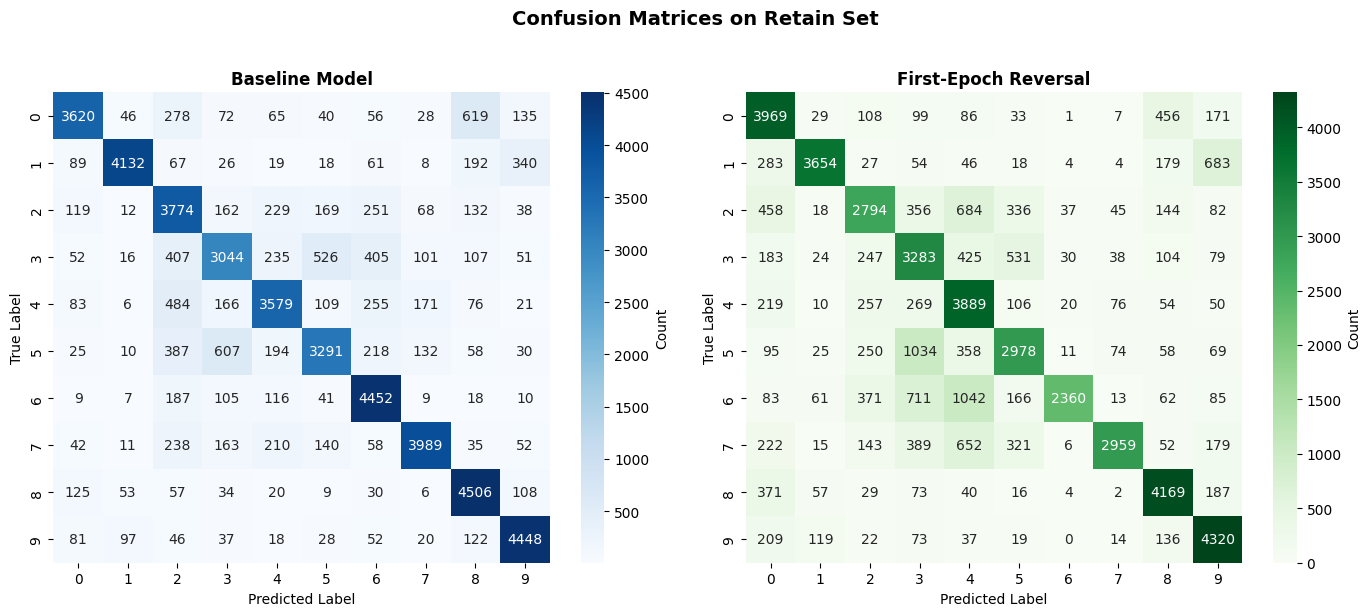

Confusion matrices visualized


In [155]:
print("\n" + "="*70)
print("CONFUSION MATRIX COMPARISON - Baseline vs Unlearned")
print("="*70)

# Create side-by-side confusion matrices (RETAIN set)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_confusion_matrix(baseline_cm, "Baseline Model", ax=axes[0], cmap='Blues')
plot_confusion_matrix(unlearned_cm, "First-Epoch Reversal", ax=axes[1], cmap='Greens')

plt.suptitle('Confusion Matrices on Retain Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot(fig, "plot_03_confusion_matrix_comparison_retain.png")
plt.show()

print("Confusion matrices visualized")

In [156]:
print("\n" + "="*70)
print("PER-CLASS ACCURACY COMPARISON (RETAIN SET)")
print("="*70)

# Create comparison dataframe
comparison_data = {
    'Digit': list(range(10)),
    'Baseline': [baseline_per_class[d] for d in range(10)],
    'Unlearned (Reversal)': [unlearned_per_class[d] for d in range(10)],
}

# Add utility loss (drop from baseline to unlearned)
comparison_data['Utility Loss'] = [
    baseline_per_class[d] - unlearned_per_class[d] for d in range(10)
]

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Summary statistics
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"\nAverage per-class accuracy (RETAIN set):")
print(f"  Baseline:              {comparison_df['Baseline'].mean():.4f}")
print(f"  Unlearned (Reversal):  {comparison_df['Unlearned (Reversal)'].mean():.4f}")
print(f"\nAverage utility loss:    {comparison_df['Utility Loss'].mean():.4f}")
print(f"Max utility loss (most affected class): Digit {comparison_df['Utility Loss'].idxmax()} ({comparison_df['Utility Loss'].max():.4f})")
print(f"Min utility loss (least affected class): Digit {comparison_df['Utility Loss'].idxmin()} ({comparison_df['Utility Loss'].min():.4f})")


PER-CLASS ACCURACY COMPARISON (RETAIN SET)

 Digit  Baseline  Unlearned (Reversal)  Utility Loss
     0  0.729986              0.800363     -0.070377
     1  0.834410              0.737884      0.096527
     2  0.761809              0.563989      0.197820
     3  0.615696              0.664037     -0.048341
     4  0.723030              0.785657     -0.062626
     5  0.664580              0.601373      0.063207
     6  0.898668              0.476383      0.422285
     7  0.807817              0.599230      0.208586
     8  0.910671              0.842563      0.068108
     9  0.898767              0.872904      0.025864

SUMMARY

Average per-class accuracy (RETAIN set):
  Baseline:              0.7845
  Unlearned (Reversal):  0.6944

Average utility loss:    0.0901
Max utility loss (most affected class): Digit 6 (0.4223)
Min utility loss (least affected class): Digit 0 (-0.0704)



PER-CLASS ACCURACY VISUALIZATION (RETAIN SET)
Saved plot: ../results/plots/CIFAR10_first_epoch_reversal_seed_0042_delete_0p01/plot_04_per_class_accuracy_and_utility_loss.png


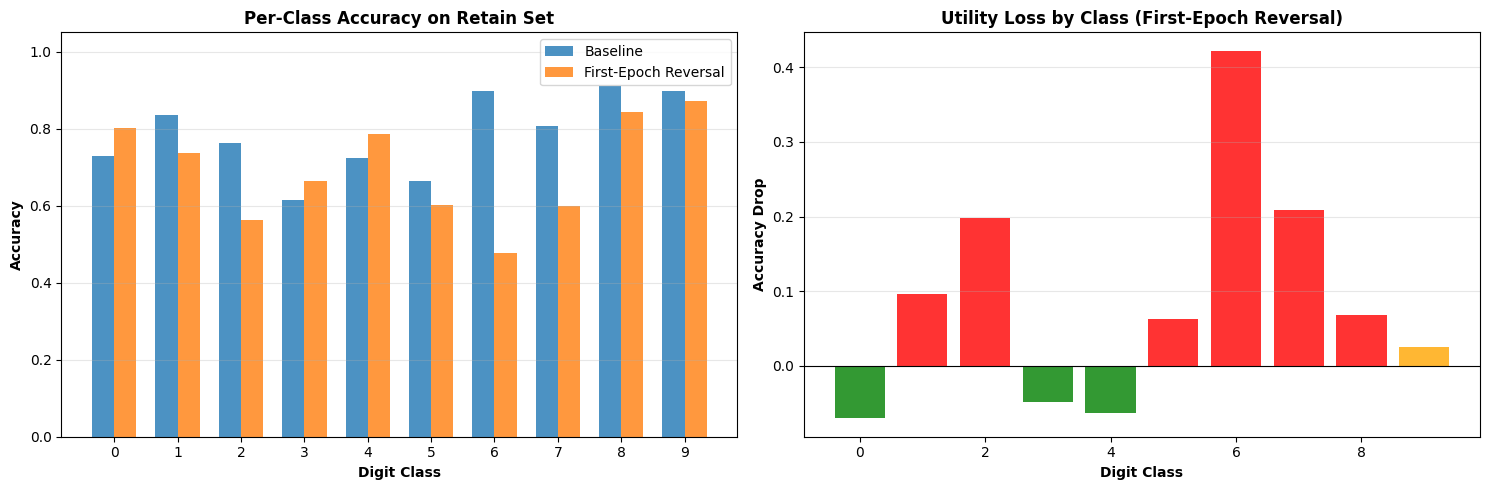

Per-class accuracy visualization complete


In [157]:
print("\nPER-CLASS ACCURACY VISUALIZATION (RETAIN SET)")

# Create bar chart comparing per-class accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Per-class accuracy for both methods
digits = list(range(10))
x = np.arange(len(digits))
width = 0.35

baseline_accs = [baseline_per_class[d] for d in range(10)]
unlearned_accs = [unlearned_per_class[d] for d in range(10)]

ax1.bar(x - width/2, baseline_accs, width, label='Baseline', alpha=0.8)
ax1.bar(x + width/2, unlearned_accs, width, label='First-Epoch Reversal', alpha=0.8)

ax1.set_xlabel('Digit Class', fontweight='bold')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Per-Class Accuracy on Retain Set', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(digits)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.05])

# Plot 2: Utility Loss (how much each class dropped with unlearning)
utility_losses = [baseline_per_class[d] - unlearned_per_class[d] for d in range(10)]
colors = ['red' if loss > 0.05 else 'orange' if loss > 0.02 else 'green' for loss in utility_losses]
ax2.bar(digits, utility_losses, color=colors, alpha=0.8)

ax2.set_xlabel('Digit Class', fontweight='bold')
ax2.set_ylabel('Accuracy Drop', fontweight='bold')
ax2.set_title('Utility Loss by Class (First-Epoch Reversal)', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
save_plot(fig, "plot_04_per_class_accuracy_and_utility_loss.png")
plt.show()

print("Per-class accuracy visualization complete")

In [158]:
# Load exact model for distance comparison
exact_model_path = f"../models/{DATASET_TAG}_gold_exact_seed_{SEED:04d}.pt"

if os.path.exists(exact_model_path):
    exact_model = SimpleCNN().to(device)
    exact_model.load_state_dict(torch.load(exact_model_path))
    exact_model.eval()
    print(f"Loaded exact model from: {exact_model_path}")
    
    # Calculate model distance metrics
    def model_distance_metrics(approx_model, exact_model):
        """Calculate L2 distance between two models."""
        sq_diff = 0.0
        sq_exact = 0.0
        
        for p_approx, p_exact in zip(approx_model.parameters(), exact_model.parameters()):
            sq_diff += torch.sum((p_approx - p_exact) ** 2)
            sq_exact += torch.sum(p_exact ** 2)
        
        abs_dist = torch.sqrt(sq_diff).item()
        norm_exact = torch.sqrt(sq_exact).item()
        rel_dist = abs_dist / (norm_exact + 1e-12)
        
        return abs_dist, rel_dist
    
    abs_l2, rel_l2 = model_distance_metrics(unlearned_model, exact_model)
    print(f"\nModel Distance Metrics:")
    print(f"  Absolute L2 Distance: {abs_l2:.4f}")
    print(f"  Relative L2 Distance: {rel_l2:.4%}")
else:
    print(f"✗ Exact model not found at {exact_model_path}")
    abs_l2 = None
    rel_l2 = None


Loaded exact model from: ../models/CIFAR10_gold_exact_seed_0042.pt

Model Distance Metrics:
  Absolute L2 Distance: 30.3968
  Relative L2 Distance: 110.1794%


In [159]:
# Prepare comprehensive results
results = {
    "experiment_info": {
        "timestamp": datetime.now().isoformat(),
        "dataset": DATASET_TAG,
        "model": "SimpleCNN",
        "deletion_ratio": DELETE_RATIO,
        "device": device,
        "seed": SEED
    },

    "first_epoch_reversal": {
        "method": "first_epoch_reversal",
        "description": "Revert to early checkpoint and retrain on retain set",
        "hyperparameters": {
            "rewind_epoch": train_meta["save_epoch"],
            "total_training_epochs": train_meta["total_epochs"],
            "retrain_epochs": RETRAIN_EPOCHS,
            "optimizer": "Adam",
            "learning_rate": LEARNING_RATE,
            "batch_size": BATCH_SIZE,
            "loss_function": LOSS_NAME
        },
        "metrics": {
            "deleted_loss": delete_metrics["loss"],
            "deleted_accuracy": delete_metrics["accuracy"],
            "retained_loss": retain_metrics["loss"],
            "retained_accuracy": retain_metrics["accuracy"]
        },
        "per_class_accuracy": {
            "retain_set": {str(digit): float(unlearned_per_class[digit]) for digit in range(10)},
            "delete_set": {str(digit): float(unlearned_delete_pc[digit]) for digit in range(10)},
        },
        "per_class_forgetting_score": {
            str(digit): float(baseline_delete_pc[digit] - unlearned_delete_pc[digit]) for digit in range(10)
        },
        "per_class_utility_loss": {
            str(digit): float(baseline_per_class[digit] - unlearned_per_class[digit]) for digit in range(10)
        },
        "time_seconds": unlearn_time,
        "distance_metrics": {
            "l2_absolute": float(abs_l2) if abs_l2 is not None else None,
            "l2_relative": float(rel_l2) if rel_l2 is not None else None,
            "metric_definition": "L2 distance from exact retrained model (gold standard)"
        }
    },
    
    "baseline_model": {
        "method": "baseline_trained_on_all_data",
        "description": "Model trained on all data (for MIA comparison)",
        "metrics": {
            "deleted_loss": baseline_delete_metrics["loss"],
            "deleted_accuracy": baseline_delete_metrics["accuracy"],
            "retained_loss": baseline_retain_metrics["loss"],
            "retained_accuracy": baseline_retain_metrics["accuracy"]
        },
        "per_class_accuracy": {
            "retain_set": {str(digit): float(baseline_per_class[digit]) for digit in range(10)},
            "delete_set": {str(digit): float(baseline_delete_pc[digit]) for digit in range(10)},
        }
    },
    
    "privacy_evaluation": {
        "method": "membership_inference_attack",
        "mia_baseline": {
            "mia_accuracy": mia_baseline["mia_accuracy"],
            "tpr": mia_baseline["tpr"],
            "fpr": mia_baseline["fpr"],
            "auc_roc": mia_baseline.get("auc_roc")
        },
        "mia_unlearned": {
            "mia_accuracy": mia_unlearned["mia_accuracy"],
            "tpr": mia_unlearned["tpr"],
            "fpr": mia_unlearned["fpr"],
            "auc_roc": mia_unlearned.get("auc_roc")
        },
        "privacy_improvement": mia_baseline["mia_accuracy"] - mia_unlearned["mia_accuracy"]
    },
    
    "saved_models": {
        "baseline_checkpoint": train_meta["checkpoint_path"],
        "baseline_full": train_meta["full_model_path"],
        "unlearned_model": unlearned_path
    }
}

print("\nResults dictionary prepared")


Results dictionary prepared


In [160]:
# Save results to JSON with formatted delete ratio
os.makedirs("../results/metadata", exist_ok=True)
delete_ratio_formatted = f"{DELETE_RATIO:.4f}".rstrip("0").rstrip(".").replace(".", "p")
filename = f"../results/metadata/{DATASET_TAG}_first_epoch_reversal_seed_{SEED:04d}_{delete_ratio_formatted}_results.json"

with open(filename, "w") as f:
    json.dump(results, f, indent=4)

print(f"\n{'='*50}")
print("RESULTS SAVED")
print(f"{'='*50}")
print(f"✓ Results JSON: {filename}")
print(f"✓ Baseline checkpoint: {train_meta['checkpoint_path']}")
print(f"✓ Baseline full model: {train_meta['full_model_path']}")
print(f"✓ Unlearned model: {unlearned_path}")


RESULTS SAVED
✓ Results JSON: ../results/metadata/CIFAR10_first_epoch_reversal_seed_0042_0p01_results.json
✓ Baseline checkpoint: ../models/CIFAR10_early_checkpoint_seed_0042_epoch0.pt
✓ Baseline full model: ../models/CIFAR10_full_model_seed_0042.pt
✓ Unlearned model: ../models/CIFAR10_reversal_unlearned_seed_0042.pt
